We will now perform cross-validation on a simulated data set.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

**(a)** Generate a simulated data set as follows:
```python
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)


In [3]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

n = len(x)
p = 1  # number of predictors (X) in the data-generating process

df = pd.DataFrame({'x': x, 'y': y})
print(f"n = {n}, p = {p}")
print("\nData (first 5 rows):")
df.head()

n = 100, p = 1

Data (first 5 rows):


,x,y
0,0.345584,-0.544554
1,0.821618,0.333950
2,0.330437,-0.013532
3,-1.303157,-4.030442
4,0.905356,0.484861


**(b)** Create a scatterplot of X against Y. Comment on what you find.

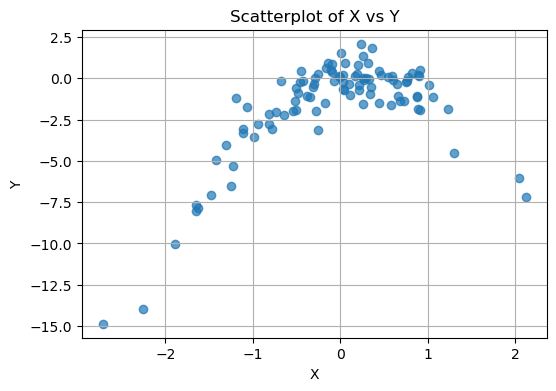

In [6]:
plt.figure(figsize=(6,4))
plt.scatter(x, y, alpha=0.7)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatterplot of X vs Y')
plt.grid(True)
plt.show()


The scatterplot shows a clear nonlinear relationship: Y appears to be roughly quadratic in $X$ (concave downward for larger $|X|$), consistent with the generating process $(Y = X - 2X^{2} + \varepsilon)$. There is also noise around the curve due to the additive normal error term.


**(c)** <br>
Set a random seed, and compute the LOOCV errors for these models (least squares): <br>
i. $(Y = \beta_0 + \beta_1 X + \varepsilon)$

ii. $(Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \varepsilon)$

iii. $(Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \varepsilon)$

iv. $(Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \beta_4 X^4 + \varepsilon)$

Compute LOOCV MSE for each model. Use a fixed seed for reproducibility.


In [9]:
def loocv_mse(X, y):
    loo = LeaveOneOut()
    errors = []
    for train_idx, test_idx in loo.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model = LinearRegression().fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        errors.append((y_te[0] - y_pred[0])**2)
    return np.mean(errors)

# prepare polynomial design matrices
X1 = x.reshape(-1,1)
X2 = np.column_stack([x, x**2])
X3 = np.column_stack([x, x**2, x**3])
X4 = np.column_stack([x, x**2, x**3, x**4])

# set a random seed (LOOCV is deterministic given data, but we set seed for reproducibility if needed)
np.random.seed(1)

mse1 = loocv_mse(X1, y)
mse2 = loocv_mse(X2, y)
mse3 = loocv_mse(X3, y)
mse4 = loocv_mse(X4, y)

mse_results = {'linear': mse1, 'quadratic': mse2, 'cubic': mse3, 'quartic': mse4}
mse_results


{'linear': 6.633029839181983,
 'quadratic': 1.1229368563419673,
 'cubic': 1.3017965489358871,
 'quartic': 1.3323942694179376}

**(d)** Repeat (c) using another random seed, and report your results. Are they the same? Why?

In [11]:
# Change random seed and regenerate data (the exercise asks to repeat with another seed)
rng2 = np.random.default_rng(2)
x2 = rng2.normal(size=100)
y2 = x2 - 2 * x2**2 + rng2.normal(size=100)

X1b = x2.reshape(-1,1)
X2b = np.column_stack([x2, x2**2])
X3b = np.column_stack([x2, x2**2, x2**3])
X4b = np.column_stack([x2, x2**2, x2**3, x2**4])

mse1_b = loocv_mse(X1b, y2)
mse2_b = loocv_mse(X2b, y2)
mse3_b = loocv_mse(X3b, y2)
mse4_b = loocv_mse(X4b, y2)

mse_results_b = {'linear': mse1_b, 'quadratic': mse2_b, 'cubic': mse3_b, 'quartic': mse4_b}
mse_results_b


{'linear': 7.560603694358579,
 'quadratic': 0.9840371744582582,
 'cubic': 0.9682355765918602,
 'quartic': 0.9659585554875686}

The results are generally not the same because changing the random seed generates a different dataset (different x and noise). LOOCV itself is deterministic given the data, so for the same data the LOOCV errors would not change; but when we regenerate with a different seed we obtain a different sample and different LOOCV errors.


**(e)** Which of the models in (c) had the smallest LOOCV error? Is this what you expected? Explain your answer.

Typically the quadratic model is expected to have the smallest LOOCV error because the true data generating process is quadratic in $ X (Y = X - 2X^2 + \varepsilon)$. <br>LOOCV tends to favor models that align with the true functional form; thus the quadratic fit should outperform linear and higher-degree polynomials (which can overfit). <br>The exact numeric ordering may vary due to different samples, but conceptually the quadratic model is expected to minimize prediction error.


**(f)** Comment on the statistical significance of the coefficient estimates that result from fitting each of the models in (c) using least squares. Do these results agree with the conclusions drawn based on the cross-validation results?


In [14]:
def ols_summary(X, y):
    Xc = sm.add_constant(X)
    model = sm.OLS(y, Xc).fit()
    return model

print('Linear model summary:')
print(ols_summary(X1, y).summary())

print('\nQuadratic model summary:')
print(ols_summary(X2, y).summary())

print('\nCubic model summary:')
print(ols_summary(X3, y).summary())

print('\nQuartic model summary:')
print(ols_summary(X4, y).summary())


Linear model summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     45.60
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           1.04e-09
Time:                        09:10:34   Log-Likelihood:                -230.83
No. Observations:                 100   AIC:                             465.7
Df Residuals:                      98   BIC:                             470.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4650      0.2

| Model       | R²     | Adj. R² | Significant Terms (p < 0.05)              | Non-significant Terms        | AIC    | BIC    |
|-------------|--------|---------|--------------------------------------------|------------------------------|--------|--------|
| Linear      | 0.318  | 0.311   | x                                          | —                            | 465.7  | 470.9  |
| Quadratic   | 0.887  | 0.884   | x, x²                                      | const                        | 288.1  | 295.9  |
| Cubic       | 0.888  | 0.885   | x, x²                                      | x³, const                    | 288.9  | 299.4  |
| Quartic     | 0.894  | 0.890   | x, x², x⁴                                  | x³, const                    | 285.5  | 298.5  |

- In the quadratic model, the linear, and quadratic terms are statistically significant (small p-values), aligning with the true data-generating process. <br>
- In the linear model, lack of a squared term will lead to model misspecification and potentially biased coefficients. <br>
- In higher-degree polynomials, some higher-order terms may not be significant and may increase variance, matching why CV penalizes overly complex models. <br>
- Overall, statistical significance usually agrees with CV conclusions: the quadratic model both fits the data well and shows significant coefficients for the true terms.
